# 03 — Paper Synthetic Batch

Create the paper-style 2×3 synthetic figure and a matched JSON batch for the base, commercial, and low-cost sensor variants. Every execution receives a unique run ID, so its raw data and figure remain reproducible for the processing and post-processing notebooks.

## Setup

In [120]:
import contextlib
import copy
import datetime as dt
import io
import json
import os
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    from IPython.display import display
except ImportError:
    display = print

CWD = pathlib.Path.cwd().resolve()
for candidate in [CWD, *CWD.parents]:
    if (candidate / "pyproject.toml").exists():
        REPO_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the repository root containing pyproject.toml.")

NOTEBOOK_DIR = REPO_ROOT / "notebooks" / "synthetic_create"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from synthetic import Generator, Simulate_Sensor
from soilgasflux_fcs import models

RUNS_ROOT = NOTEBOOK_DIR / "generated" / "03_runs"
CANONICAL_FIGURE_PATH = NOTEBOOK_DIR / "figures" / "synthetic_data.png"
RUNS_ROOT.mkdir(parents=True, exist_ok=True)
CANONICAL_FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)


## Configuration

`RUN_ID=None` creates a new UTC run ID. The optional environment variables are useful for automated execution; normal notebook runs keep the defaults shown below.

In [121]:
RUN_ID = os.environ.get("SOILGASFLUX_RUN_ID") or None
WRITE_CANONICAL_FIGURE = os.environ.get("SOILGASFLUX_WRITE_CANONICAL", "1") != "0"

RANDOM_SEED = 1337222
TOTAL_TIME = 180
C0 = 430.0
TIME = np.arange(TOTAL_TIME)

INTENSITY_TARGETS = {
    "low": 40.0,
    "medium": 88.0,
    "high": 178.0,
}
CURVE_ALPHA = {
    "linear": 1.0e-5,
    "convex": 3.0e-3,
}
CURVE_ORDER = ["linear", "convex"]
INTENSITY_ORDER = ["low", "medium", "high"]
SENSOR_ORDER = ["base", "commercial", "low-cost"]
SENSOR_LABELS = {
    "base": "Perfect curve",
    "commercial": "Commercial setting",
    "low-cost": "Low-cost setting",
}

CHAMBER = {
    "area": float(np.pi * 20**2 / 4),
    "volume": float(np.pi * 20**2 * 20 / 4),
}
ENVIRONMENT = {
    "pressure_pa": 99000.0,
    "temperature_c": 20.0,
    "humidity_percent": 70.0,
}
SENSOR_SETTINGS = {
    "base": None,
    "commercial": {
        "response_time": 1,
        "gas_analyzer_volume": 50,
        "sensor_accuracy": 10,
        "sensor_precision": 10,
        "pump_volume": 25,
        "pump_rate": 250,
        "additional_volume": 25,
        "with_diffusion": True,
        "with_advection": True,
    },
    "low-cost": {
        "response_time": 10,
        "gas_analyzer_volume": 50,
        "sensor_accuracy": 5,
        "sensor_precision": 5,
        "pump_volume": 25,
        "pump_rate": 250,
        "additional_volume": 25,
        "with_diffusion": True,
        "with_advection": True,
    },
}

COLORS = {
    "base": "black",
    # "commercial": "#f5b99f",
    "commercial": "#e71212",
    "low-cost": "#15e43e",
}
LINEWIDTHS = {"base": 2.2, "commercial": 2.0, "low-cost": 2.0}


## Generation and Export Helpers

In [131]:
def solve_cs(c0, alpha, target_delta, total_time):
    end_time = total_time - 1
    return float(c0 + target_delta / (1 - np.exp(-alpha * end_time)))


def generate_base_config(curve_type, intensity):
    alpha = CURVE_ALPHA[curve_type]
    cs = solve_cs(C0, alpha, INTENSITY_TARGETS[intensity], TOTAL_TIME)
    generator = Generator(total_time=TOTAL_TIME, c0=C0)
    return generator.generate_base(
        alpha=alpha,
        cs=cs,
        c0=C0,
        t0=0,
        total_time=TOTAL_TIME,
        deadband=0,
        background_band=0,
        unmixed_phase=0,
        unmixed_disturbance_intensity=0,
        mixed_phase_disturbance=0,
        disturbance_intensity=0,
        disturbance_starting_point=0,
        add_noise=False,
        noise_intensity=0,
        curvature=curve_type,
        noise_type=None,
    )


def simulate_sensor_trace(config, sensor_type, random_seed):
    if sensor_type == "base":
        return np.asarray(config["final_value"], dtype=float)

    hardware = SENSOR_SETTINGS[sensor_type]
    source_dcdt = models.hm_model_dcdt(
        t0=config["t0"],
        c0=config["c_c0"],
        a=config["alpha"],
        cx=config["c_s"],
        t=TIME,
    )
    simulator = Simulate_Sensor(
        alpha=config["alpha"],
        cs=config["c_s"],
        t0=config["t0"],
        c0=config["c_c0"],
        total_time=config["total_time"],
        dt=1,
    )

    state = np.random.get_state()
    np.random.seed(random_seed)
    try:
        with contextlib.redirect_stdout(io.StringIO()):
            simulator.chamber_settings(
                area=CHAMBER["area"],
                chamber_volume=CHAMBER["volume"],
            )
            simulator.gasAnalyzer_settings(
                response_time=hardware["response_time"],
                gasAnalyzer_volume=hardware["gas_analyzer_volume"],
                sensor_accuracy=hardware["sensor_accuracy"],
                sensor_precision=hardware["sensor_precision"],
            )
            simulator.internal_pump_settings(
                pump_volume=hardware["pump_volume"],
                pump_rate=hardware["pump_rate"],
            )
            simulator.additional_settings(volume=hardware["additional_volume"])
            trace = simulator.run_simulation(
                source_ppm=source_dcdt,
                with_diffusion=hardware["with_diffusion"],
                with_advection=hardware["with_advection"],
                verbose=False,
            )
    finally:
        np.random.set_state(state)
    return np.asarray(trace, dtype=float)


def raw_json_payload(config, values, start_time, scenario_id, curve_type, intensity, sensor_type, seed):
    timestamps = [start_time + dt.timedelta(seconds=int(second)) for second in TIME]
    n = len(values)
    json_config = {
        key: value
        for key, value in copy.deepcopy(config).items()
        if key != "final_value"
    }
    json_config.update(
        {
            "final_value": None,
            "scenario_id": scenario_id,
            "curve_type": curve_type,
            "intensity": intensity,
            "sensor_type": sensor_type,
            "sensor_settings": copy.deepcopy(SENSOR_SETTINGS[sensor_type]),
            "random_seed": int(seed),
        }
    )
    return {
        "raw_data": {
            "datetime": list(range(n)),
            "datetime_utc": [value.strftime("%Y-%m-%d %H:%M:%S") for value in timestamps],
            "k30_co2": np.asarray(values, dtype=float).tolist(),
            "bmp_pressure": [ENVIRONMENT["pressure_pa"]] * n,
            "bmp_temperature": [ENVIRONMENT["temperature_c"]] * n,
            "si_humidity": [ENVIRONMENT["humidity_percent"]] * n,
            "si_temperature": [ENVIRONMENT["temperature_c"]] * n,
        },
        "config": json_config,
    }


def write_json(path, payload):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        json.dump(payload, handle, indent=2)


def plot_paper_figure(dataset, save_paths):
    cm = 1 / 2.54
    fig, axes = plt.subplots(
        len(CURVE_ORDER),
        len(INTENSITY_ORDER),
        figsize=(19 * cm, 12 * cm),
        sharex=True,
        dpi=300,
    )
    plot_order = ["commercial","low-cost",  "base"]

    for row, curve_type in enumerate(CURVE_ORDER):
        for col, intensity in enumerate(INTENSITY_ORDER):
            ax = axes[row, col]
            panel = dataset[
                (dataset["curve_type"] == curve_type)
                & (dataset["intensity"] == intensity)
            ]
            for sensor_type in plot_order:
                trace = panel[panel["sensor_type"] == sensor_type]
                ax.plot(
                    trace["time"],
                    trace["co2_ppm"],
                    color=COLORS[sensor_type],
                    linewidth=LINEWIDTHS[sensor_type],
                    label=SENSOR_LABELS[sensor_type],
                    # label=SENSOR_SETTINGS[sensor_type]["sensor_accuracy"] if sensor_type != "base" else SENSOR_LABELS[sensor_type],
                    zorder=plot_order.index(sensor_type) + 1,
                )
            ax.set_title(
                f"Curve type: {curve_type}\nFlux intensity: {intensity}",
                fontsize=13,
            )
            ax.set_xticks(np.arange(0, TOTAL_TIME + 1, 30))
            ax.tick_params(axis="x", labelrotation=45)
            ax.tick_params(axis="both", labelsize=10)
            for spine in ax.spines.values():
                spine.set_linewidth(0.8)
            if row == len(CURVE_ORDER) - 1:
                ax.set_xlabel("Time [s]", fontsize=12)

    fig.supylabel(r"$CO_2$ Concentration [ppm]", fontsize=13, x=0.015)
    handles_by_label = {}
    for ax in axes.ravel():
        handles, labels = ax.get_legend_handles_labels()
        handles_by_label.update(dict(zip(labels, handles)))
    labels = [SENSOR_LABELS[sensor] for sensor in SENSOR_ORDER]
    fig.legend(
        # [handles_by_label[label] for label in labels],
        # ['Perfect curve', 'Sensor precision: 10 ppm', 'Sensor precision: 5 ppm'],
        ['Sensor precision: 10 ppm', 'Sensor precision: 5 ppm', 'Perfect curve'],
        # labels,
        loc="lower center",
        ncol=3,
        frameon=True,
        bbox_to_anchor=(0.5, -0.02),
        fontsize=10,
    )
    fig.subplots_adjust(
        left=0.09,
        right=0.99,
        top=0.93,
        bottom=0.2,
        wspace=0.34,
        hspace=0.42,
    )
    for save_path in save_paths:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    return fig


## Create the Matched Batch

,scenario_id,curve_type,intensity,alpha,c_s,c0,t0
0,linear_low,linear,low,0.00001,22796.374682,430.0,0.0
1,linear_medium,linear,medium,0.00001,49636.024300,430.0,0.0
2,linear_high,linear,high,0.00001,99960.367334,430.0,0.0
3,convex_low,convex,low,0.00300,526.269351,430.0,0.0
4,convex_medium,convex,medium,0.00300,641.792573,430.0,0.0
5,convex_high,convex,high,0.00300,858.398614,430.0,0.0


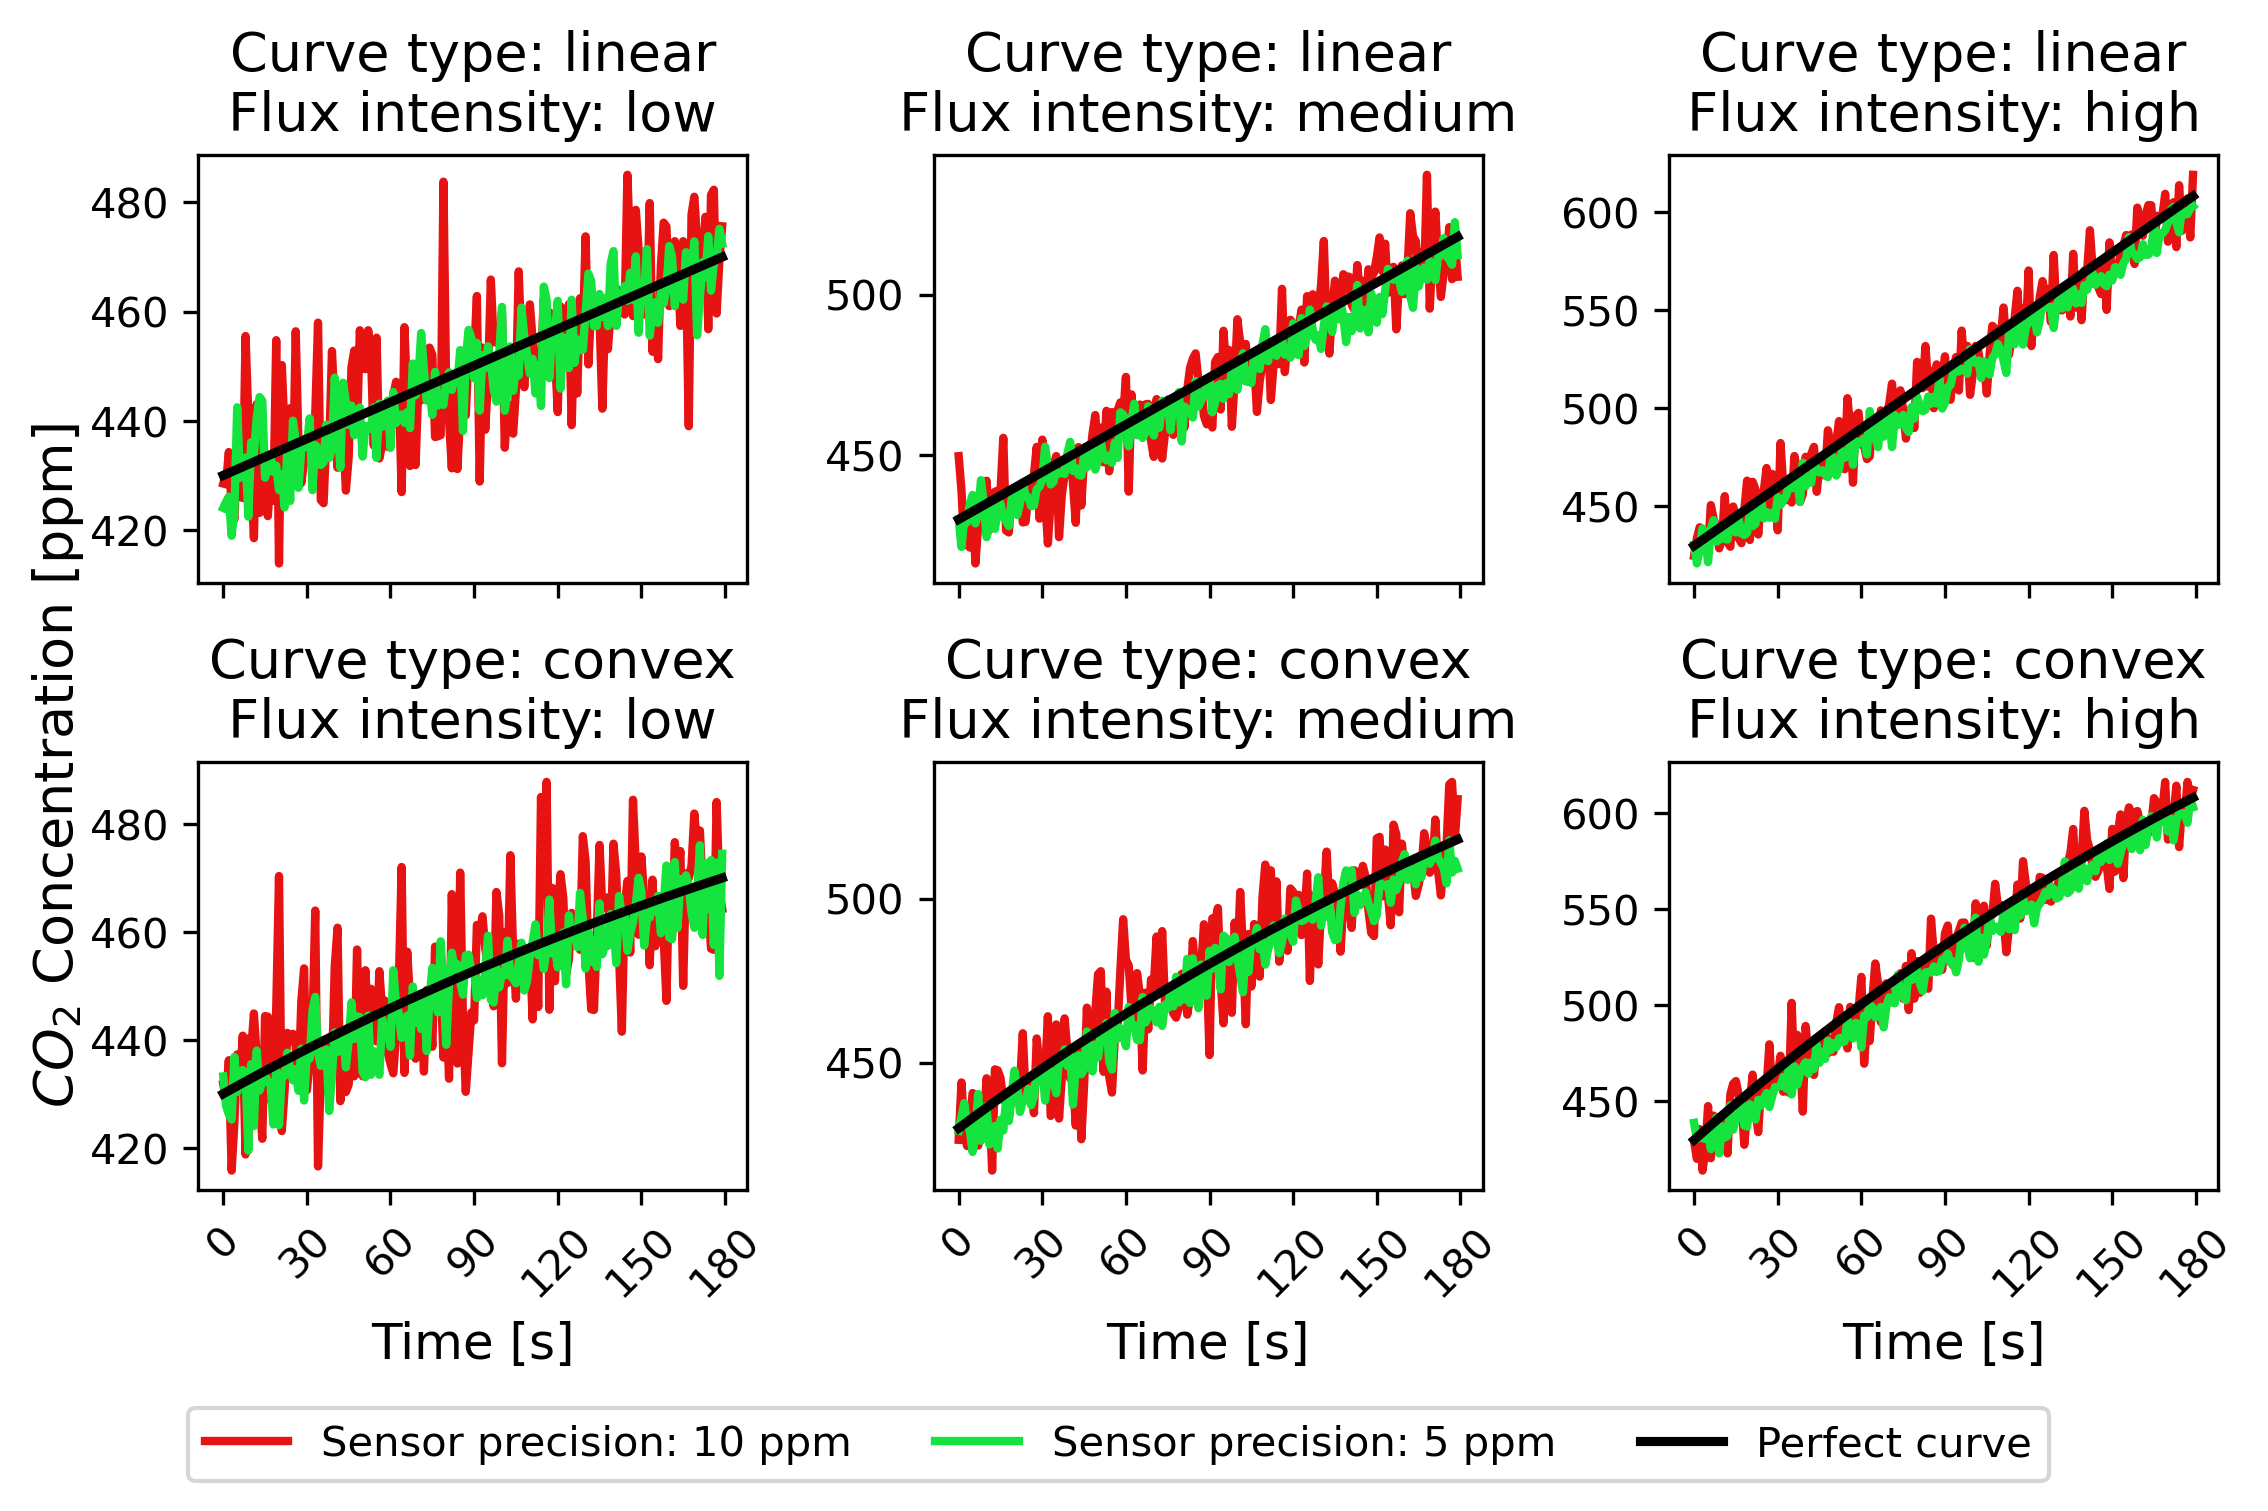

In [132]:
created_at = dt.datetime.now(dt.timezone.utc)
run_id = RUN_ID or created_at.strftime("%Y%m%dT%H%M%S%fZ")
run_dir = RUNS_ROOT / run_id
if run_dir.exists():
    raise FileExistsError(
        f"Run folder already exists: {run_dir}. Use RUN_ID=None or choose a new explicit RUN_ID."
    )

# Synthetic timestamps are identifiers rather than observations. Starting at noon
# keeps the complete batch within one processing date while matching all sensors.
batch_start = created_at.replace(hour=12, minute=0, second=0, microsecond=0, tzinfo=None)
records = []
scenario_records = []

for curve_index, curve_type in enumerate(CURVE_ORDER):
    for intensity_index, intensity in enumerate(INTENSITY_ORDER):
        scenario_index = curve_index * len(INTENSITY_ORDER) + intensity_index
        scenario_id = f"{curve_type}_{intensity}"
        start_time = batch_start + dt.timedelta(seconds=scenario_index * (TOTAL_TIME + 60))
        base_config = generate_base_config(curve_type, intensity)
        files = {}
        seeds = {}

        for sensor_index, sensor_type in enumerate(SENSOR_ORDER):
            seed = RANDOM_SEED + 100 * curve_index + 10 * intensity_index + sensor_index
            values = simulate_sensor_trace(base_config, sensor_type, random_seed=seed)
            relative_path = pathlib.Path(sensor_type) / f"{scenario_id}.json"
            write_json(
                run_dir / relative_path,
                raw_json_payload(
                    base_config,
                    values,
                    start_time,
                    scenario_id,
                    curve_type,
                    intensity,
                    sensor_type,
                    seed,
                ),
            )
            files[sensor_type] = relative_path.as_posix()
            seeds[sensor_type] = int(seed)
            records.extend(
                {
                    "time": int(second),
                    "co2_ppm": float(co2),
                    "scenario_id": scenario_id,
                    "curve_type": curve_type,
                    "intensity": intensity,
                    "sensor_type": sensor_type,
                }
                for second, co2 in zip(TIME, values)
            )

        scenario_records.append(
            {
                "scenario_id": scenario_id,
                "curve_type": curve_type,
                "intensity": intensity,
                "start_time_utc": start_time.strftime("%Y-%m-%d %H:%M:%S"),
                "total_time_seconds": TOTAL_TIME,
                "ideal_parameters": {
                    "alpha": float(base_config["alpha"]),
                    "c_s": float(base_config["c_s"]),
                    "c0": float(base_config["c_c0"]),
                    "t0": float(base_config["t0"]),
                },
                "sensor_seeds": seeds,
                "files": files,
            }
        )

manifest = {
    "schema_version": 1,
    "run_id": run_id,
    "created_at_utc": created_at.isoformat(),
    "batch_start_utc": batch_start.strftime("%Y-%m-%d %H:%M:%S"),
    "random_seed": RANDOM_SEED,
    "chamber": CHAMBER,
    "environment": ENVIRONMENT,
    "sensor_settings": SENSOR_SETTINGS,
    "curve_order": CURVE_ORDER,
    "intensity_order": INTENSITY_ORDER,
    "sensor_order": SENSOR_ORDER,
    "scenarios": scenario_records,
}
write_json(run_dir / "manifest.json", manifest)

dataset = pd.DataFrame.from_records(records)
figure_paths = [run_dir / "synthetic_data.png"]
if WRITE_CANONICAL_FIGURE:
    figure_paths.append(CANONICAL_FIGURE_PATH)
fig = plot_paper_figure(dataset, figure_paths)

parameter_table = pd.DataFrame(
    {
        "scenario_id": scenario["scenario_id"],
        "curve_type": scenario["curve_type"],
        "intensity": scenario["intensity"],
        **scenario["ideal_parameters"],
    }
    for scenario in scenario_records
)
parameter_table


## Validate the Batch

In [133]:
def validate_generated_batch(run_dir, manifest):
    expected_ids = [
        f"{curve}_{intensity}"
        for curve in CURVE_ORDER
        for intensity in INTENSITY_ORDER
    ]
    actual_ids = [scenario["scenario_id"] for scenario in manifest["scenarios"]]
    if actual_ids != expected_ids:
        raise ValueError(f"Unexpected scenario order: {actual_ids}")

    timestamps_by_scenario = {}
    for sensor_type in SENSOR_ORDER:
        files = sorted((run_dir / sensor_type).glob("*.json"))
        if [path.stem for path in files] != sorted(expected_ids):
            raise ValueError(
                f"{sensor_type!r} does not contain the expected six scenario JSON files."
            )
        for path in files:
            with path.open(encoding="utf-8") as handle:
                payload = json.load(handle)
            raw = payload.get("raw_data", {})
            config = payload.get("config", {})
            lengths = {len(raw.get(key, [])) for key in ["datetime_utc", "k30_co2", "bmp_pressure", "si_temperature", "si_humidity"]}
            if lengths != {TOTAL_TIME}:
                raise ValueError(f"Invalid raw-data lengths in {path}: {sorted(lengths)}")
            required_config = {
                "scenario_id",
                "curve_type",
                "intensity",
                "sensor_type",
                "sensor_settings",
                "alpha",
                "c_s",
                "c_c0",
            }
            missing = required_config - set(config)
            if missing:
                raise ValueError(f"Missing config fields in {path}: {sorted(missing)}")
            timestamps = raw["datetime_utc"]
            previous = timestamps_by_scenario.setdefault(path.stem, timestamps)
            if timestamps != previous:
                raise ValueError(f"Timestamp mismatch across sensors for {path.stem}.")

    if not (run_dir / "synthetic_data.png").exists():
        raise FileNotFoundError("The run-specific synthetic figure was not created.")
    return {
        "run_id": manifest["run_id"],
        "run_folder": str(run_dir),
        "scenario_count": len(expected_ids),
        "json_file_count": len(expected_ids) * len(SENSOR_ORDER),
        "figure": str(run_dir / "synthetic_data.png"),
    }


batch_summary = validate_generated_batch(run_dir, manifest)
display(batch_summary)
print(f"Next: run notebooks/processing/03_process_synthetic_batch.ipynb with RUN_ID={run_id!r}, or leave RUN_ID=None to select this latest run.")


{'run_id': '20260805T121749739703Z',
 'run_folder': '/Users/alexnaokiasatokobayashi/git/soilgasflux_fcs/notebooks/synthetic_create/generated/03_runs/20260805T121749739703Z',
 'scenario_count': 6,
 'json_file_count': 18,
 'figure': '/Users/alexnaokiasatokobayashi/git/soilgasflux_fcs/notebooks/synthetic_create/generated/03_runs/20260805T121749739703Z/synthetic_data.png'}

Next: run notebooks/processing/03_process_synthetic_batch.ipynb with RUN_ID='20260805T121749739703Z', or leave RUN_ID=None to select this latest run.
